In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
import tifffile as tiff
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from PIL import Image

import joblib

# Cached version
class UnlabeledTIFFDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = [
            os.path.join(root_dir, fname)
            for fname in os.listdir(root_dir)
            if fname.lower().endswith(('tif', 'tiff'))
        ]

        self.data = []
        for img_path in self.image_paths:
            try:
                image = tiff.imread(img_path).astype(np.float32)
                image = image * 240
                image[image > 254] = 254
                if image.ndim == 3:
                    image = image[0]
                image = image / 255

                if self.transform:
                    image = self.transform(image)
                image = torch.tensor(image, dtype=torch.float32)  # shape: (1, H, W)
                self.data.append(image)
            except Exception as e:
                print(f"Warning: Skipping unreadable image {img_path} - {e}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]

        # Ensure it's a torch tensor
        if not isinstance(image, torch.Tensor):
            image = torch.tensor(image, dtype=torch.float32)

        # # Ensure shape is [1, H, W]
        # if image.ndim == 2:  # [H, W]
        #     image = image.unsqueeze(0)
        # elif image.ndim == 3 and image.shape[0] != 1:
        #     # If image is [C, H, W] but C != 1, take the first channel
        #     image = image[0].unsqueeze(0)

        return image, 0  # Dummy label


# Step 1: Define a standard Autoencoder (AE)
import torch
import numpy as np
from tqdm import tqdm
from torchvision import transforms
from skimage import io
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

class AE(torch.nn.Module):
    def __init__(self, latent_dim=8):
        super(AE, self).__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Conv2d(1, 32, 3, stride=2, padding=1),  # 32 -> 16
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 16 -> 8
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.Conv2d(64, 128, 3, stride=2, padding=1),  # 8 -> 4
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),
            torch.nn.Flatten()
        )
        self.encoder_fc = torch.nn.Sequential(
            torch.nn.Linear(128 * 4 * 4, 1024),
            torch.nn.LeakyReLU(0.01),
            torch.nn.Dropout(p=0.3),
            torch.nn.Linear(1024, latent_dim)
        )

        self.decoder_fc = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, 1024),
            torch.nn.LeakyReLU(0.01),
            torch.nn.Dropout(p=0.3),
            torch.nn.Linear(1024, 128 * 4 * 4)
        )

        self.decoder = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),  # 4 -> 8
            torch.nn.BatchNorm2d(64),
            torch.nn.LeakyReLU(0.01),
            torch.nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),  # 8 -> 16
            torch.nn.BatchNorm2d(32),
            torch.nn.LeakyReLU(0.01),
            torch.nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),   # 16 -> 32
            torch.nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        return self.encoder_fc(x)

    def decode(self, z):
        x = self.decoder_fc(z).view(-1, 128, 4, 4)
        return self.decoder(x)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z
    
def plot_reconstruction_progress(model, dataloader, device, epoch):
    """Plot original vs reconstructed images during training"""
    model.eval()
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            recon, _ = model(x)
            break  # only one batch

    x = x.cpu()
    recon = recon.cpu()

    print(f"Input stats — min: {x.min().item():.4f}, max: {x.max().item():.4f}, mean: {x.mean().item():.4f}, std: {x.std().item():.4f}")
    print(f"Reconstruction stats — min: {recon.min().item():.4f}, max: {recon.max().item():.4f}, mean: {recon.mean().item():.4f}, std: {recon.std().item():.4f}")

    n = min(8, x.size(0))
    fig, axes = plt.subplots(2, n, figsize=(n * 1, 2))
    for i in range(n):
        axes[0, i].imshow(x[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[0, i].axis("off")
        axes[1, i].imshow(recon[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[1, i].axis("off")
    plt.suptitle(f"Reconstruction at Epoch {epoch}")
    plt.tight_layout()
    plt.show()

import time

# Step 2: Train Autoencoder and Extract Latent Representations
def train_ae(model, train_loader, val_loader, epochs=2000, lr=1e-4):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss = 0.0
        for x, _ in train_loader:
            x = x.to(device)
            recon, _ = model(x)
            loss = loss_fn(recon, x)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                recon, _ = model(x)
                loss = loss_fn(recon, x)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        end_time = time.time()
        epoch_time = end_time - start_time

        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Time: {epoch_time:.2f} sec")
            
        if (epoch + 1) % 500 == 0:
            plot_reconstruction_progress(model, val_loader, device, epoch + 1)
            

    # Plot training and validation loss
    plt.plot(range(epochs), train_losses, label='Train Loss')
    plt.plot(range(epochs), val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training vs Validation Loss')
    plt.show()

    return model


# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from torch.utils.data import ConcatDataset

dir1 = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/patches_gridonly_pslocation00/tiff_patches32_65p_20250909_1521'
dir2 = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/y_ch1_major/y_ch1_patches_gridonly_pslocation00/tiff_patches32_65p_20250909_1532'

transform = transforms.Compose([transforms.ToTensor()])

ds1 = UnlabeledTIFFDataset(root_dir=dir1, transform=transform)
ds2 = UnlabeledTIFFDataset(root_dir=dir2, transform=transform)



dataset = ConcatDataset([ds1, ds2])


# Split dataset into training and validation sets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

joblib.dump(train_loader, "train_loader_pax_ch1_ps32_ctrl_Y_grid_00_10000epoch.pkl")




/tmp/ipykernel_1260161/2259968877.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)  # shape: (1, H, W)


['train_loader_pax_ch1_ps32_ctrl_Y_grid_00_10000epoch.pkl']

In [2]:
len(dataset)

6586

Epoch 100/10000, Train Loss: 0.0098, Val Loss: 0.0108, Time: 0.13 sec
Epoch 200/10000, Train Loss: 0.0088, Val Loss: 0.0110, Time: 0.15 sec
Epoch 300/10000, Train Loss: 0.0081, Val Loss: 0.0116, Time: 0.14 sec
Epoch 400/10000, Train Loss: 0.0076, Val Loss: 0.0118, Time: 0.13 sec
Epoch 500/10000, Train Loss: 0.0072, Val Loss: 0.0120, Time: 0.14 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1233, std: 0.1521
Reconstruction stats — min: 0.0032, max: 0.9601, mean: 0.1209, std: 0.1136


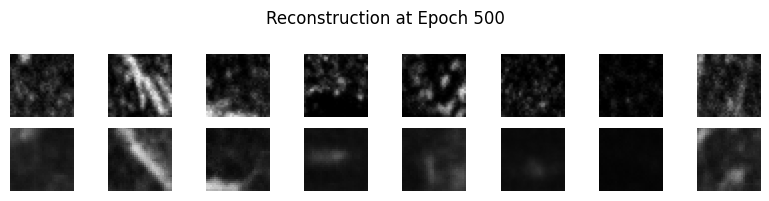

Epoch 600/10000, Train Loss: 0.0069, Val Loss: 0.0124, Time: 0.16 sec
Epoch 700/10000, Train Loss: 0.0066, Val Loss: 0.0124, Time: 0.12 sec
Epoch 800/10000, Train Loss: 0.0064, Val Loss: 0.0126, Time: 0.14 sec
Epoch 900/10000, Train Loss: 0.0063, Val Loss: 0.0128, Time: 0.13 sec
Epoch 1000/10000, Train Loss: 0.0060, Val Loss: 0.0130, Time: 0.14 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1233, std: 0.1521
Reconstruction stats — min: 0.0025, max: 0.9327, mean: 0.1214, std: 0.1112


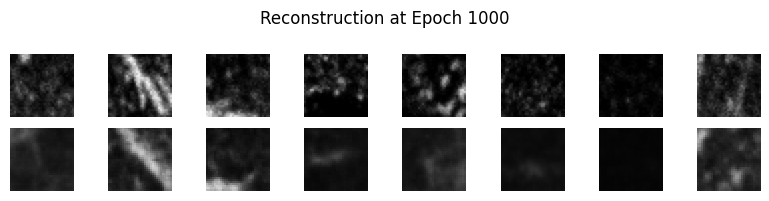

Epoch 1100/10000, Train Loss: 0.0059, Val Loss: 0.0130, Time: 0.14 sec
Epoch 1200/10000, Train Loss: 0.0058, Val Loss: 0.0131, Time: 0.15 sec
Epoch 1300/10000, Train Loss: 0.0056, Val Loss: 0.0132, Time: 0.13 sec
Epoch 1400/10000, Train Loss: 0.0055, Val Loss: 0.0133, Time: 0.16 sec
Epoch 1500/10000, Train Loss: 0.0054, Val Loss: 0.0133, Time: 0.15 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1233, std: 0.1521
Reconstruction stats — min: 0.0007, max: 0.9164, mean: 0.1169, std: 0.1107


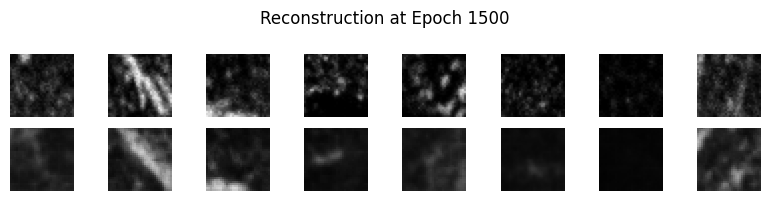

Epoch 1600/10000, Train Loss: 0.0053, Val Loss: 0.0134, Time: 0.14 sec
Epoch 1700/10000, Train Loss: 0.0052, Val Loss: 0.0134, Time: 0.14 sec
Epoch 1800/10000, Train Loss: 0.0052, Val Loss: 0.0135, Time: 0.14 sec
Epoch 1900/10000, Train Loss: 0.0051, Val Loss: 0.0134, Time: 0.14 sec
Epoch 2000/10000, Train Loss: 0.0051, Val Loss: 0.0135, Time: 0.16 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1233, std: 0.1521
Reconstruction stats — min: 0.0003, max: 0.9366, mean: 0.1149, std: 0.1110


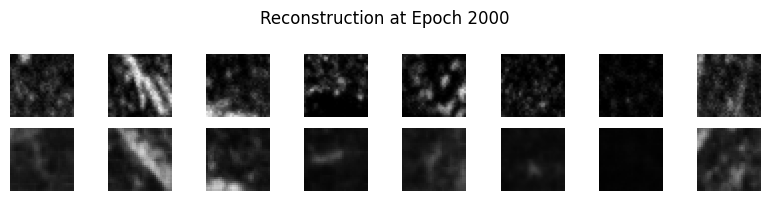

Epoch 2100/10000, Train Loss: 0.0050, Val Loss: 0.0136, Time: 0.15 sec
Epoch 2200/10000, Train Loss: 0.0049, Val Loss: 0.0137, Time: 0.15 sec
Epoch 2300/10000, Train Loss: 0.0049, Val Loss: 0.0136, Time: 0.15 sec
Epoch 2400/10000, Train Loss: 0.0049, Val Loss: 0.0137, Time: 0.15 sec
Epoch 2500/10000, Train Loss: 0.0048, Val Loss: 0.0136, Time: 0.16 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1233, std: 0.1521
Reconstruction stats — min: 0.0005, max: 0.9351, mean: 0.1199, std: 0.1120


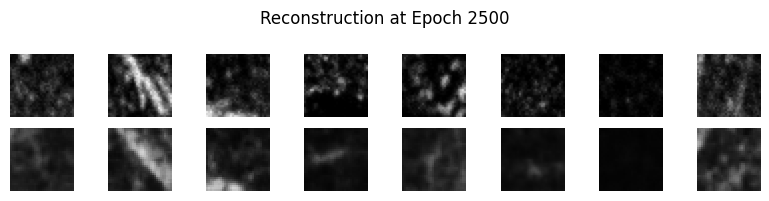

Epoch 2600/10000, Train Loss: 0.0047, Val Loss: 0.0137, Time: 0.14 sec
Epoch 2700/10000, Train Loss: 0.0047, Val Loss: 0.0137, Time: 0.19 sec
Epoch 2800/10000, Train Loss: 0.0047, Val Loss: 0.0137, Time: 0.16 sec
Epoch 2900/10000, Train Loss: 0.0046, Val Loss: 0.0138, Time: 0.16 sec
Epoch 3000/10000, Train Loss: 0.0046, Val Loss: 0.0138, Time: 0.14 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1233, std: 0.1521
Reconstruction stats — min: 0.0005, max: 0.9537, mean: 0.1173, std: 0.1091


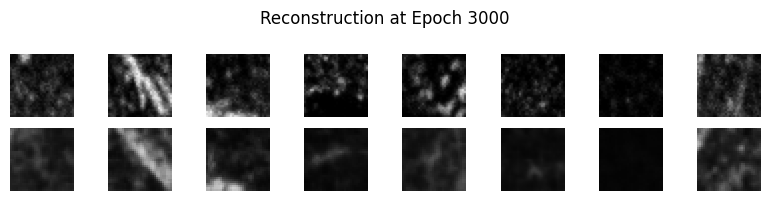

Epoch 3100/10000, Train Loss: 0.0046, Val Loss: 0.0138, Time: 0.16 sec
Epoch 3200/10000, Train Loss: 0.0046, Val Loss: 0.0138, Time: 0.15 sec
Epoch 3300/10000, Train Loss: 0.0045, Val Loss: 0.0138, Time: 0.16 sec
Epoch 3400/10000, Train Loss: 0.0045, Val Loss: 0.0139, Time: 0.15 sec
Epoch 3500/10000, Train Loss: 0.0045, Val Loss: 0.0139, Time: 0.15 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1233, std: 0.1521
Reconstruction stats — min: 0.0008, max: 0.9534, mean: 0.1199, std: 0.1089


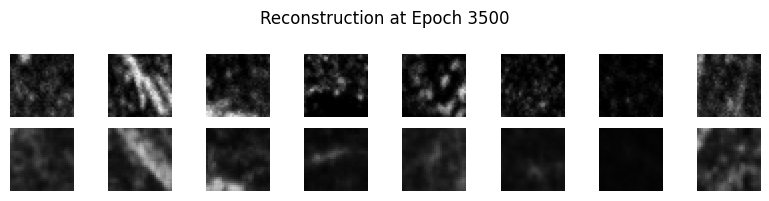

Epoch 3600/10000, Train Loss: 0.0045, Val Loss: 0.0139, Time: 0.14 sec
Epoch 3700/10000, Train Loss: 0.0044, Val Loss: 0.0139, Time: 0.15 sec
Epoch 3800/10000, Train Loss: 0.0044, Val Loss: 0.0139, Time: 0.13 sec
Epoch 3900/10000, Train Loss: 0.0044, Val Loss: 0.0140, Time: 0.13 sec
Epoch 4000/10000, Train Loss: 0.0043, Val Loss: 0.0139, Time: 0.13 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1233, std: 0.1521
Reconstruction stats — min: 0.0006, max: 0.9493, mean: 0.1158, std: 0.1068


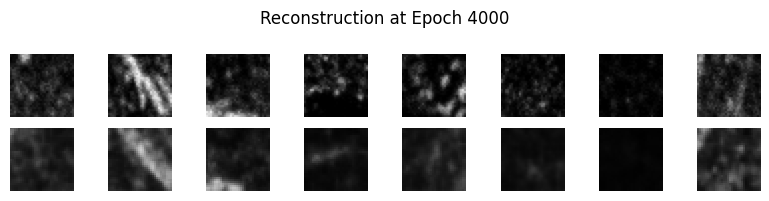

Epoch 4100/10000, Train Loss: 0.0044, Val Loss: 0.0140, Time: 0.14 sec
Epoch 4200/10000, Train Loss: 0.0043, Val Loss: 0.0141, Time: 0.13 sec
Epoch 4300/10000, Train Loss: 0.0043, Val Loss: 0.0140, Time: 0.16 sec
Epoch 4400/10000, Train Loss: 0.0043, Val Loss: 0.0140, Time: 0.13 sec
Epoch 4500/10000, Train Loss: 0.0043, Val Loss: 0.0140, Time: 0.13 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1233, std: 0.1521
Reconstruction stats — min: 0.0005, max: 0.9405, mean: 0.1133, std: 0.1077


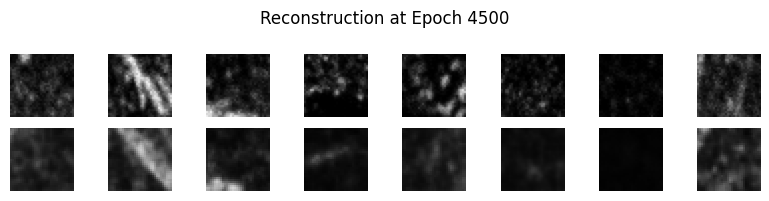

Epoch 4600/10000, Train Loss: 0.0043, Val Loss: 0.0140, Time: 0.13 sec
Epoch 4700/10000, Train Loss: 0.0043, Val Loss: 0.0140, Time: 0.14 sec
Epoch 4800/10000, Train Loss: 0.0042, Val Loss: 0.0141, Time: 0.14 sec
Epoch 4900/10000, Train Loss: 0.0042, Val Loss: 0.0141, Time: 0.14 sec
Epoch 5000/10000, Train Loss: 0.0042, Val Loss: 0.0141, Time: 0.15 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1233, std: 0.1521
Reconstruction stats — min: 0.0005, max: 0.9427, mean: 0.1195, std: 0.1086


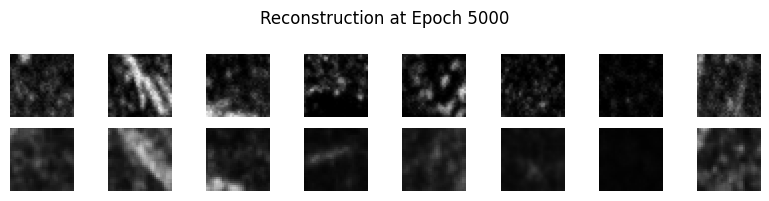

Epoch 5100/10000, Train Loss: 0.0042, Val Loss: 0.0141, Time: 0.16 sec
Epoch 5200/10000, Train Loss: 0.0042, Val Loss: 0.0142, Time: 0.15 sec
Epoch 5300/10000, Train Loss: 0.0042, Val Loss: 0.0141, Time: 0.13 sec
Epoch 5400/10000, Train Loss: 0.0042, Val Loss: 0.0142, Time: 0.14 sec
Epoch 5500/10000, Train Loss: 0.0041, Val Loss: 0.0140, Time: 0.13 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1233, std: 0.1521
Reconstruction stats — min: 0.0004, max: 0.9265, mean: 0.1162, std: 0.1068


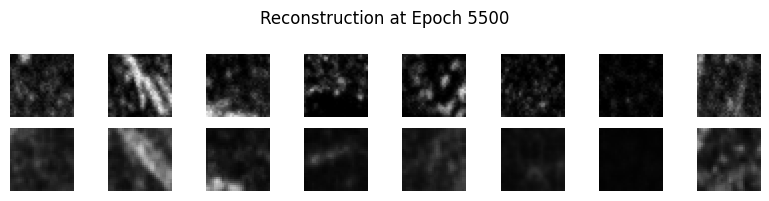

Epoch 5600/10000, Train Loss: 0.0041, Val Loss: 0.0141, Time: 0.14 sec
Epoch 5700/10000, Train Loss: 0.0042, Val Loss: 0.0142, Time: 0.16 sec
Epoch 5800/10000, Train Loss: 0.0041, Val Loss: 0.0142, Time: 0.13 sec
Epoch 5900/10000, Train Loss: 0.0041, Val Loss: 0.0141, Time: 0.13 sec
Epoch 6000/10000, Train Loss: 0.0041, Val Loss: 0.0142, Time: 0.13 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1233, std: 0.1521
Reconstruction stats — min: 0.0007, max: 0.9399, mean: 0.1206, std: 0.1073


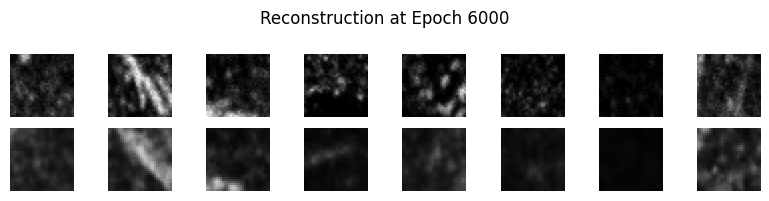

Epoch 6100/10000, Train Loss: 0.0041, Val Loss: 0.0142, Time: 0.14 sec
Epoch 6200/10000, Train Loss: 0.0041, Val Loss: 0.0144, Time: 0.13 sec
Epoch 6300/10000, Train Loss: 0.0041, Val Loss: 0.0142, Time: 0.13 sec
Epoch 6400/10000, Train Loss: 0.0041, Val Loss: 0.0143, Time: 0.15 sec
Epoch 6500/10000, Train Loss: 0.0041, Val Loss: 0.0143, Time: 0.16 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1233, std: 0.1521
Reconstruction stats — min: 0.0005, max: 0.9388, mean: 0.1211, std: 0.1080


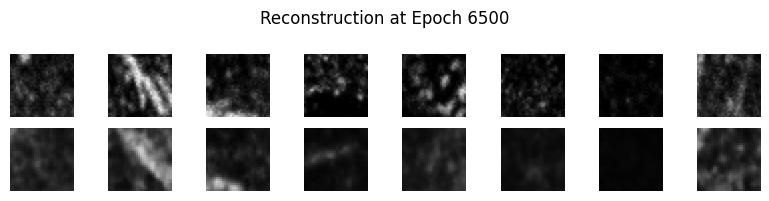

Epoch 6600/10000, Train Loss: 0.0040, Val Loss: 0.0143, Time: 0.14 sec
Epoch 6700/10000, Train Loss: 0.0041, Val Loss: 0.0142, Time: 0.15 sec
Epoch 6800/10000, Train Loss: 0.0041, Val Loss: 0.0142, Time: 0.13 sec
Epoch 6900/10000, Train Loss: 0.0040, Val Loss: 0.0142, Time: 0.16 sec
Epoch 7000/10000, Train Loss: 0.0041, Val Loss: 0.0142, Time: 0.13 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1233, std: 0.1521
Reconstruction stats — min: 0.0007, max: 0.9313, mean: 0.1174, std: 0.1079


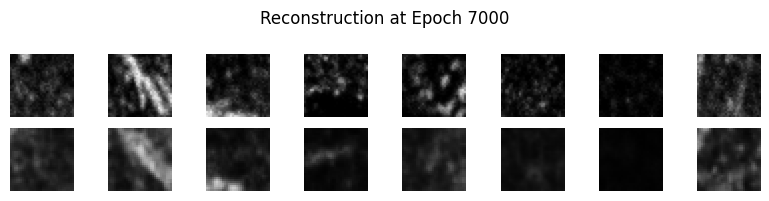

Epoch 7100/10000, Train Loss: 0.0040, Val Loss: 0.0143, Time: 0.14 sec
Epoch 7200/10000, Train Loss: 0.0040, Val Loss: 0.0143, Time: 0.13 sec
Epoch 7300/10000, Train Loss: 0.0040, Val Loss: 0.0143, Time: 0.14 sec
Epoch 7400/10000, Train Loss: 0.0040, Val Loss: 0.0143, Time: 0.14 sec
Epoch 7500/10000, Train Loss: 0.0040, Val Loss: 0.0143, Time: 0.13 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1233, std: 0.1521
Reconstruction stats — min: 0.0006, max: 0.9295, mean: 0.1213, std: 0.1090


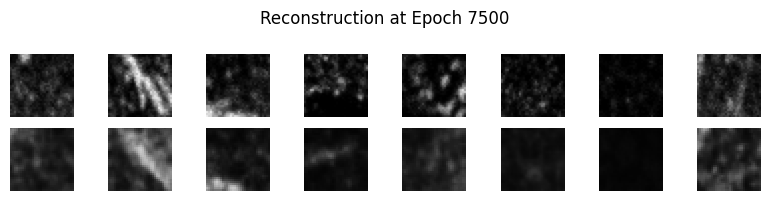

Epoch 7600/10000, Train Loss: 0.0040, Val Loss: 0.0142, Time: 0.14 sec
Epoch 7700/10000, Train Loss: 0.0040, Val Loss: 0.0143, Time: 0.13 sec
Epoch 7800/10000, Train Loss: 0.0040, Val Loss: 0.0142, Time: 0.14 sec
Epoch 7900/10000, Train Loss: 0.0040, Val Loss: 0.0143, Time: 0.14 sec
Epoch 8000/10000, Train Loss: 0.0040, Val Loss: 0.0144, Time: 0.14 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1233, std: 0.1521
Reconstruction stats — min: 0.0006, max: 0.9293, mean: 0.1226, std: 0.1089


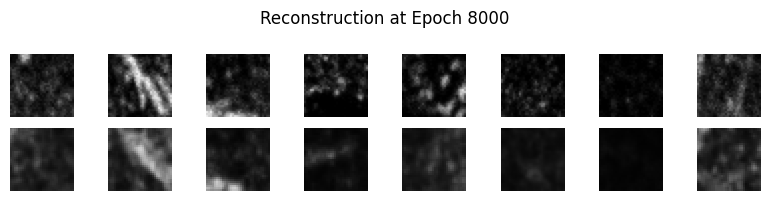

Epoch 8100/10000, Train Loss: 0.0040, Val Loss: 0.0144, Time: 0.15 sec
Epoch 8200/10000, Train Loss: 0.0040, Val Loss: 0.0143, Time: 0.14 sec
Epoch 8300/10000, Train Loss: 0.0039, Val Loss: 0.0144, Time: 0.16 sec
Epoch 8400/10000, Train Loss: 0.0040, Val Loss: 0.0145, Time: 0.13 sec
Epoch 8500/10000, Train Loss: 0.0040, Val Loss: 0.0145, Time: 0.13 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1233, std: 0.1521
Reconstruction stats — min: 0.0006, max: 0.9337, mean: 0.1217, std: 0.1077


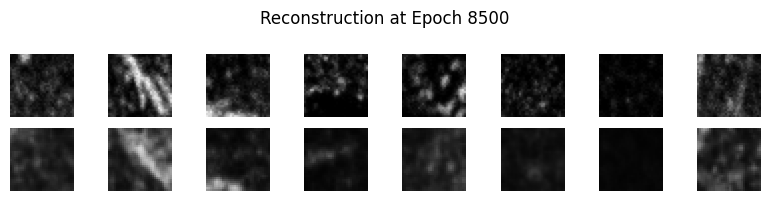

Epoch 8600/10000, Train Loss: 0.0039, Val Loss: 0.0145, Time: 0.14 sec
Epoch 8700/10000, Train Loss: 0.0040, Val Loss: 0.0144, Time: 0.14 sec
Epoch 8800/10000, Train Loss: 0.0039, Val Loss: 0.0143, Time: 0.13 sec
Epoch 8900/10000, Train Loss: 0.0040, Val Loss: 0.0145, Time: 0.13 sec
Epoch 9000/10000, Train Loss: 0.0039, Val Loss: 0.0144, Time: 0.14 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1233, std: 0.1521
Reconstruction stats — min: 0.0006, max: 0.9296, mean: 0.1175, std: 0.1062


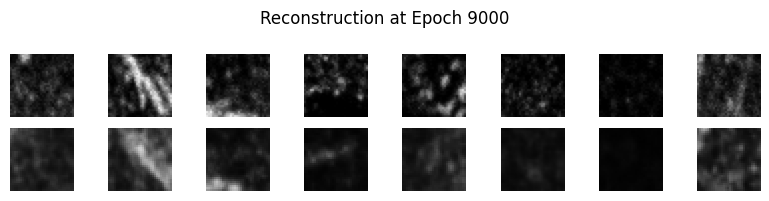

Epoch 9100/10000, Train Loss: 0.0039, Val Loss: 0.0143, Time: 0.15 sec
Epoch 9200/10000, Train Loss: 0.0039, Val Loss: 0.0144, Time: 0.13 sec
Epoch 9300/10000, Train Loss: 0.0039, Val Loss: 0.0144, Time: 0.14 sec
Epoch 9400/10000, Train Loss: 0.0039, Val Loss: 0.0144, Time: 0.15 sec
Epoch 9500/10000, Train Loss: 0.0039, Val Loss: 0.0144, Time: 0.19 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1233, std: 0.1521
Reconstruction stats — min: 0.0006, max: 0.9312, mean: 0.1200, std: 0.1066


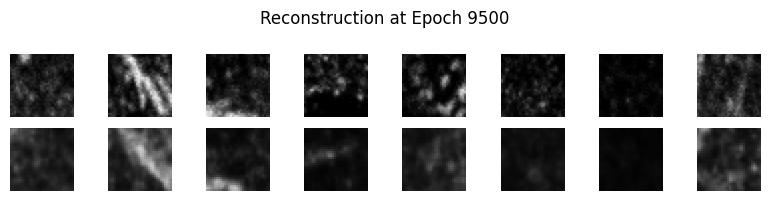

Epoch 9600/10000, Train Loss: 0.0039, Val Loss: 0.0143, Time: 0.13 sec
Epoch 9700/10000, Train Loss: 0.0039, Val Loss: 0.0143, Time: 0.13 sec
Epoch 9800/10000, Train Loss: 0.0039, Val Loss: 0.0144, Time: 0.13 sec
Epoch 9900/10000, Train Loss: 0.0039, Val Loss: 0.0145, Time: 0.14 sec
Epoch 10000/10000, Train Loss: 0.0039, Val Loss: 0.0145, Time: 0.16 sec
Input stats — min: 0.0000, max: 0.9486, mean: 0.1233, std: 0.1521
Reconstruction stats — min: 0.0008, max: 0.9344, mean: 0.1218, std: 0.1079


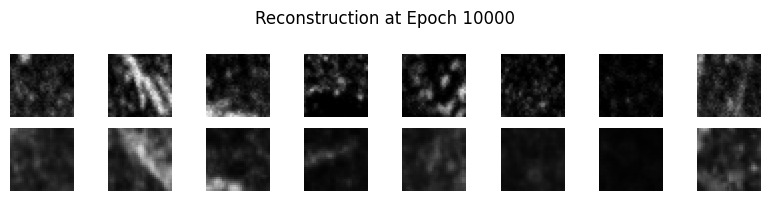

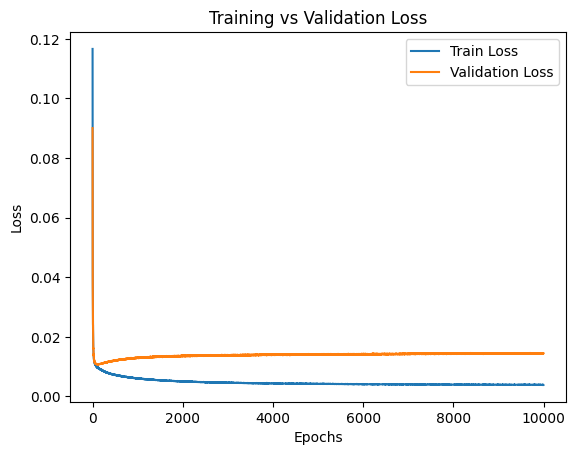

In [3]:
# Train AE
ae = AE().to(device)
ae = train_ae(ae, train_loader, val_loader,epochs=10000)

torch.save(ae, 'pax_ch1_ps32_ctrl_Y_grid_00_BN_bestmodel_10000epoch.pt')

In [4]:
len(ds1)

4205

In [5]:
len(ds2)


2381

In [6]:
import torch
import numpy as np
from tqdm import tqdm
from torchvision import transforms
from skimage import io
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from umap import UMAP


# Step 3: Cluster in Latent Space

def cluster_latents(model, dataloader, num_clusters=6):
    model.eval()
    latents = []
    images = []
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            _, z = model(x)
            latents.append(z.cpu().numpy())
            images.append(x.cpu())
    latents = np.concatenate(latents, axis=0)
    images = torch.cat(images, dim=0)

       # Save model
    joblib.dump(latents, "latents_8d_pax_ch1_BN_ps32_ctrl_Y_grid_00_10000epoch.pkl")
    joblib.dump(images, "train_images__pax_ch1_BN_ps32_ctrl_Y_grid_00_10000epoch.pkl")


    kmeans = KMeans(n_clusters=num_clusters, random_state=0).fit(latents)
    labels = kmeans.labels_

    # Save the model
    joblib.dump(kmeans, "kmeans_model_pax_ch1_BN_ps32_ctrl_Y_grid_00_10000epoch.pkl")
    return latents, labels, images

# Step 4: Visualize Clusters with t-SNE and Reconstructed Images

def visualize_clusters(latents, labels, images, model):


    umap = UMAP(n_components=2, random_state=42)
    latents_2d = umap.fit_transform(latents)

    # Save model
    joblib.dump(latents_2d, "latents_2d_pax_ch1_BN_ps32_ctrl_Y_grid_00_10000epoch.pkl")


    # Save model
    joblib.dump(umap, "umap_model_pax_ch1_BN_ps32_ctrl_Y_grid_00_10000epoch.pkl")

    plt.figure(figsize=(5, 3.5))
    plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels, cmap='tab10', alpha=0.7, s=1)
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title("2D Visualization of Latent Space using UMAP")
    plt.show()

    selected_images = []
    selected_labels = set()
    for i, label in enumerate(labels):
        if label not in selected_labels:
            selected_labels.add(label)
            selected_images.append(images[i])
        if len(selected_labels) == 4:
            break

    selected_images = torch.stack(selected_images).to(device)
    reconstructed, _ = model(selected_images)

    fig, axes = plt.subplots(2, len(selected_images), figsize=(15, 5))
    for i in range(len(selected_images)):
        axes[0, i].imshow(selected_images[i].squeeze().cpu(), cmap='gray', vmax=1.0, vmin=0)
        axes[1, i].imshow(reconstructed[i].squeeze().cpu().detach(), cmap='gray', vmax=1.0, vmin=0)
        axes[0, i].axis('off')
        axes[1, i].axis('off')
    plt.show()
    return latents_2d


In [7]:
import torch
import numpy as np
from tqdm import tqdm
from torchvision import transforms
from skimage import io
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE


# Step 5: Show multiple decoded images per cluster

def cluster_and_display_images(latents, labels, images, model, num_samples_per_cluster=10):
    unique_labels = np.unique(labels)
    fig, axes = plt.subplots(len(unique_labels)*2, num_samples_per_cluster, figsize=(num_samples_per_cluster*1.5, len(unique_labels)*2))

    for cluster_idx, cluster_label in enumerate(unique_labels):
        cluster_indices = np.where(labels == cluster_label)[0][:num_samples_per_cluster]
        cluster_images = images[cluster_indices].to(device)
        recon_images, _ = model(cluster_images)

        for i in range(num_samples_per_cluster):
            axes[2 * cluster_idx, i].imshow(cluster_images[i].squeeze().cpu(), cmap='gray', vmin=0, vmax=1.0)
            axes[2 * cluster_idx + 1, i].imshow(recon_images[i].squeeze().cpu().detach(), cmap='gray', vmin=0, vmax=1.0)
            axes[2 * cluster_idx, i].axis('off')
            axes[2 * cluster_idx + 1, i].axis('off')

    plt.tight_layout()
    plt.show()


In [8]:
def cluster_2Dplot(latents, ind1,ind2,labels):
    plt.figure(figsize=(8, 6))
    plt.scatter(latents[:, ind1], latents[:, ind2], c=labels, cmap='tab10', alpha=0.7, s=1)
    plt.xlabel("F1")
    plt.ylabel("F2")
    plt.title("2D Visualization of Latent Space F0-F1")
    plt.show()
    

In [9]:
def cluster_3Dplot(latents, ind1,ind2,ind3, labels):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(latents[:, ind1], latents[:, ind2],latents[:, ind3], c=labels, cmap='tab10',s=1)
    plt.xlabel('F'+str(ind1))
    plt.ylabel('F'+str(ind2))
    plt.ylabel('F'+str(ind3))
    plt.title('3D Visualization of Latent Space F' +str(ind1)+'-'+str(ind2)+'-'+str(ind3))
    plt.show()
    

In [10]:
latents, labels, images = cluster_latents(ae, train_loader, num_clusters=6)


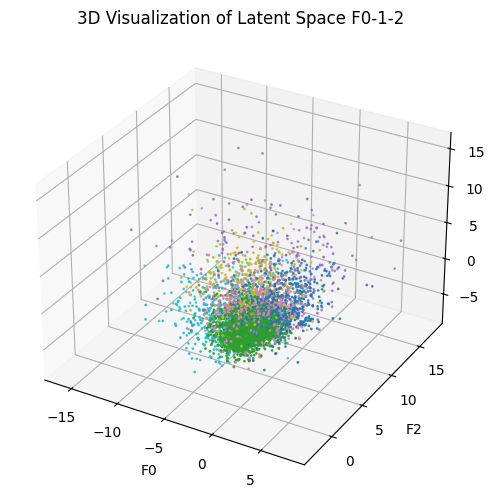

In [11]:
cluster_3Dplot(latents, 0,1,2,labels)

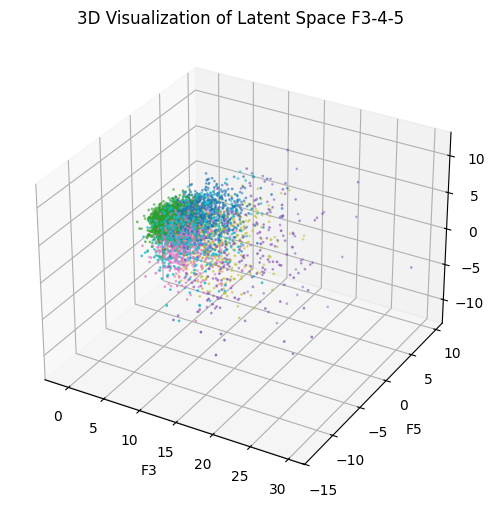

In [12]:
cluster_3Dplot(latents, 3,4,5,labels)

In [13]:
images.shape

torch.Size([5268, 1, 32, 32])

In [14]:
pax_ctrl_loader = DataLoader(ds1, batch_size=128, shuffle=False)
pax_y_loader = DataLoader(ds2, batch_size=128, shuffle=False)

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


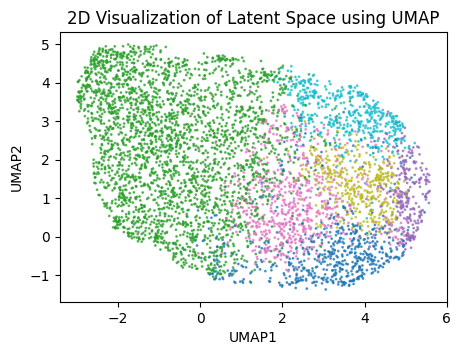

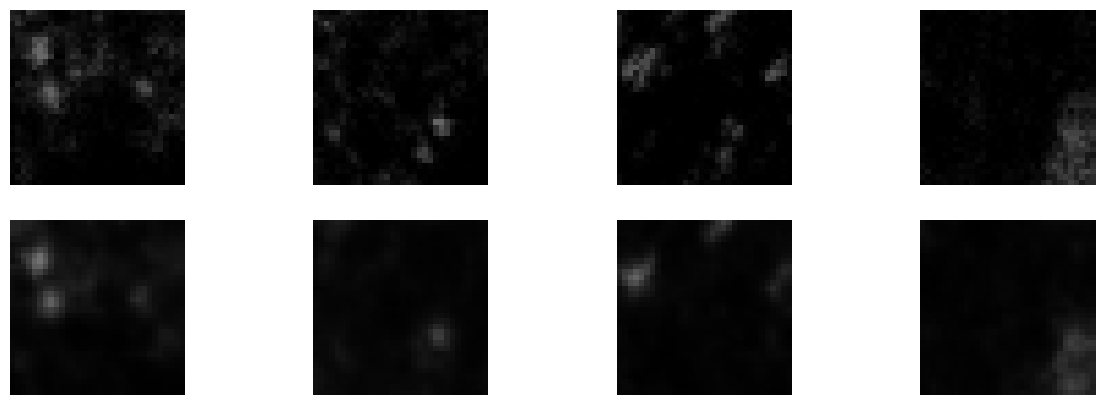

In [15]:
latents_2d = visualize_clusters(latents, labels, images, ae)


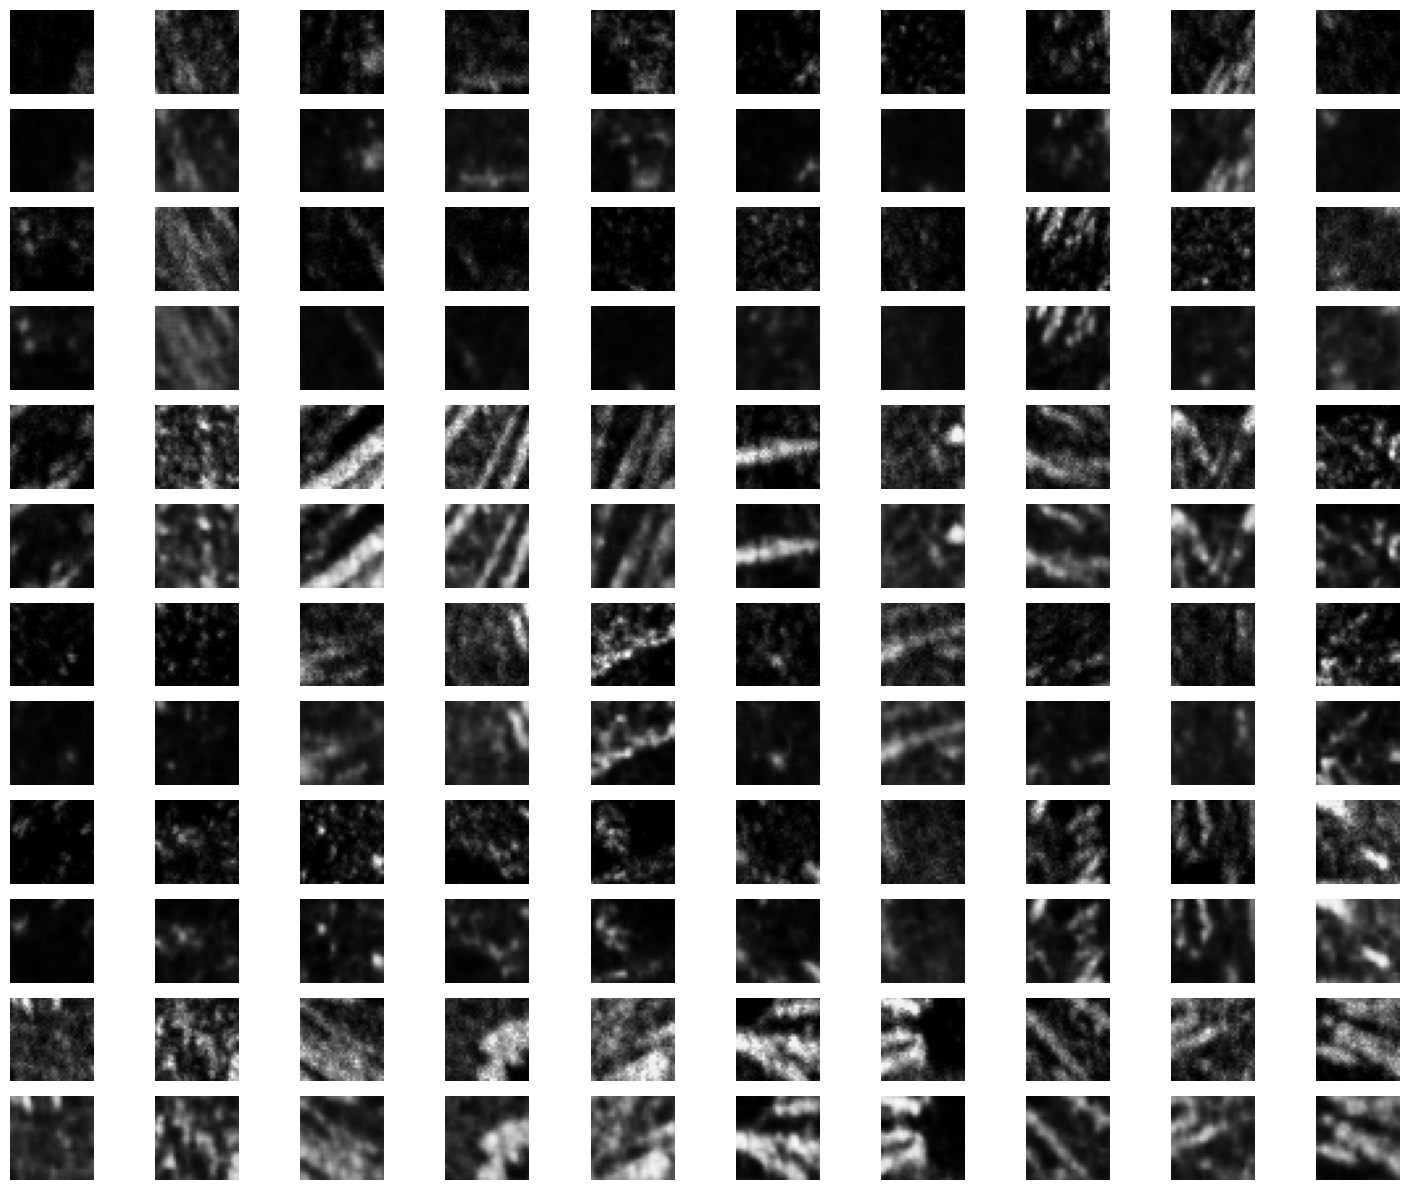

In [16]:
cluster_and_display_images(latents, labels, images, ae, num_samples_per_cluster=10)
